<a href="https://colab.research.google.com/github/Rigtsu/hw/blob/main/hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

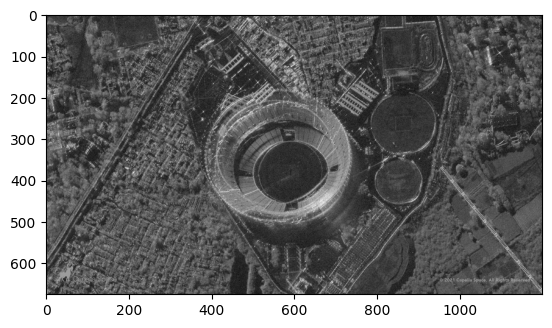

In [ ]:
plt.imshow(image_gray, cmap="gray")

In [ ]:
#шум гаусс
mean = 0
stddev = 100

noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,   0,   3, ...,   0,   0,   0],
       [  0,   0,   0, ...,  90,  10,   0],
       [ 21,   0,   0, ...,  85,   0,   0],
       ...,
       [  0,   0,  23, ...,  63,   0,  65],
       [  0, 217,   0, ..., 149,   0,  22],
       [121,   0, 183, ...,  31,   0,  97]], dtype=uint8)

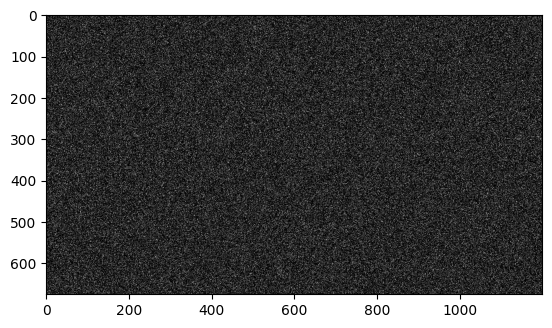

In [ ]:
plt.imshow(noise_gauss, cmap="gray")

In [ ]:
#постоянный шум
constant_noise = 50

image_noise_constant = np.clip(
    image_gray.astype(np.int16) + constant_noise,
    0, 255
).astype(np.uint8)

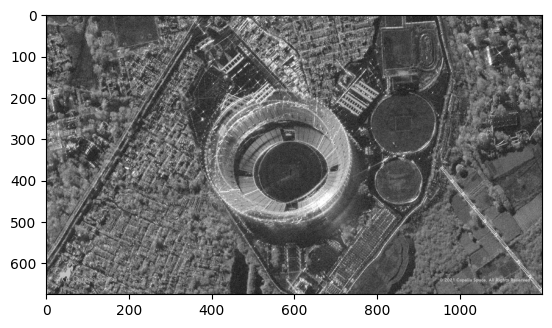

In [ ]:
plt.imshow(image_noise_constant, cmap="gray")

In [ ]:
# медианный фильтр для гауссовского шума
median_gauss_3 = cv2.medianBlur(image_noise_gauss, 3)
median_gauss_5 = cv2.medianBlur(image_noise_gauss, 5)
median_gauss_7 = cv2.medianBlur(image_noise_gauss, 7)

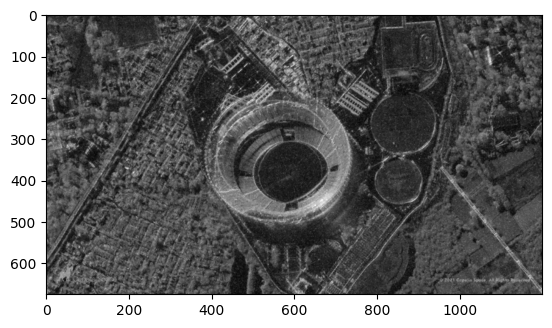

In [ ]:
plt.imshow(median_gauss_3, cmap="gray")

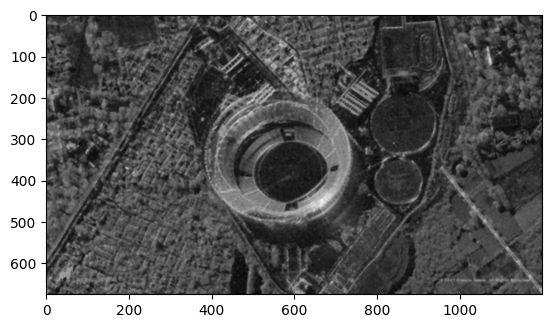

In [ ]:
plt.imshow(median_gauss_5, cmap="gray")

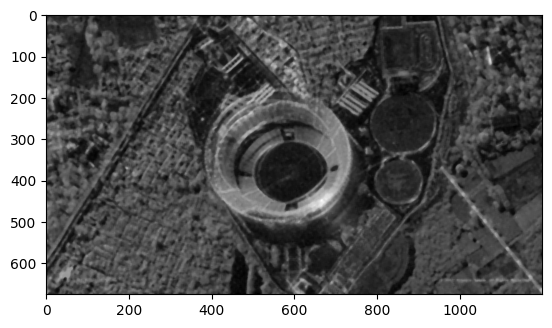

In [ ]:
plt.imshow(median_gauss_7, cmap="gray")

In [ ]:
gauss_3 = cv2.GaussianBlur(image_noise_gauss, (3, 3), 0)
gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
gauss_7 = cv2.GaussianBlur(image_noise_gauss, (7, 7), 0)

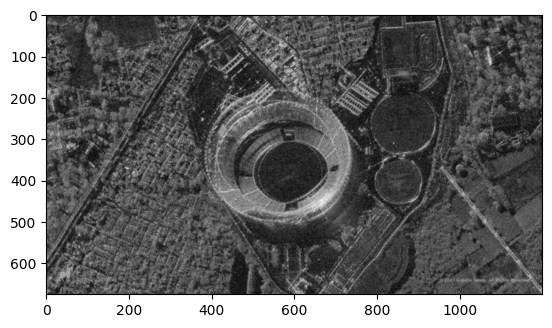

In [ ]:
plt.imshow(gauss_3, cmap="gray")

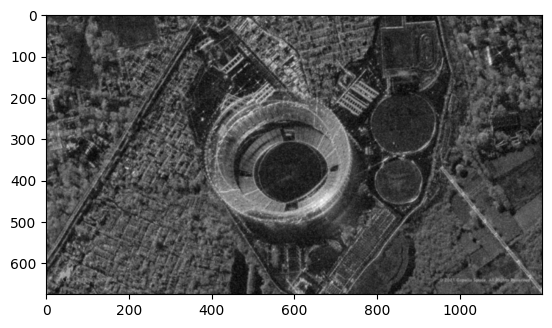

In [ ]:
plt.imshow(gauss_5, cmap="gray")

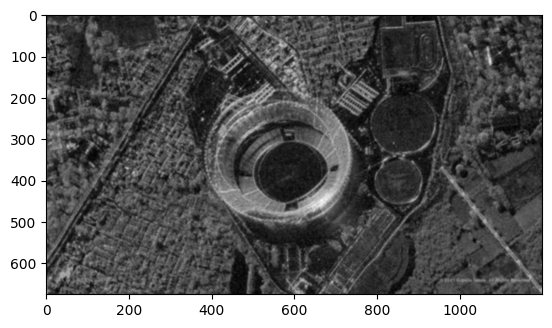

In [ ]:
plt.imshow(gauss_7, cmap="gray")

In [ ]:
bilateral_1 = cv2.bilateralFilter(image_noise_gauss, 5, 30, 30)
bilateral_2 = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
bilateral_3 = cv2.bilateralFilter(image_noise_gauss, 15, 100, 100)

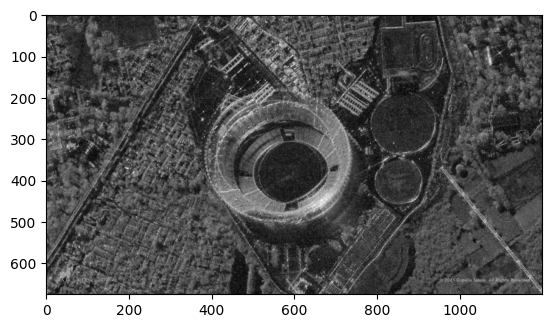

In [ ]:
plt.imshow(bilateral_1, cmap="gray")

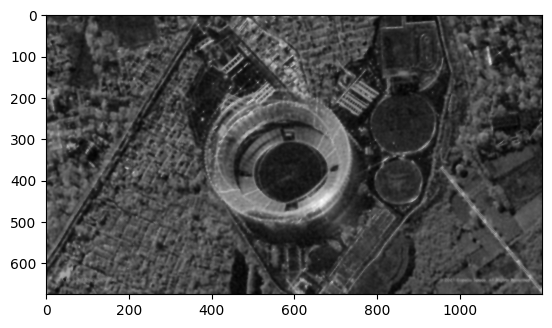

In [ ]:
plt.imshow(bilateral_2, cmap="gray")

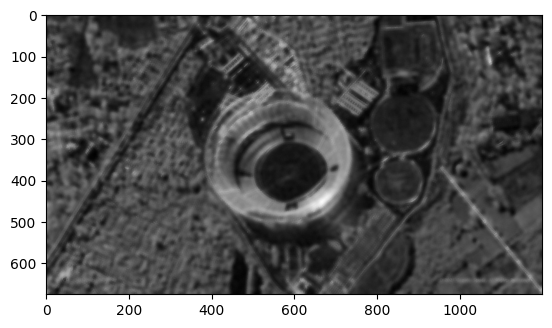

In [ ]:
plt.imshow(bilateral_3, cmap="gray")

In [ ]:
nlm_1 = cv2.fastNlMeansDenoising(image_noise_gauss, None, 10, 7, 21)
nlm_2 = cv2.fastNlMeansDenoising(image_noise_gauss, None, 20, 7, 21)
nlm_3 = cv2.fastNlMeansDenoising(image_noise_gauss, None, 30, 7, 21)

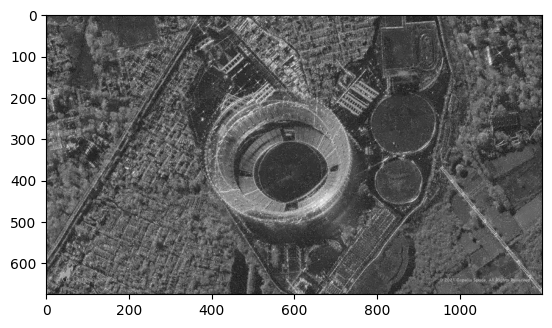

In [ ]:
plt.imshow(nlm_1, cmap="gray")

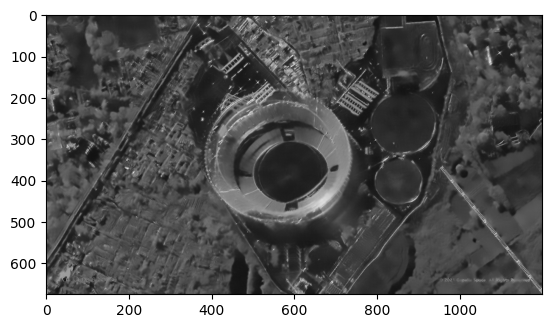

In [ ]:
plt.imshow(nlm_2, cmap="gray")

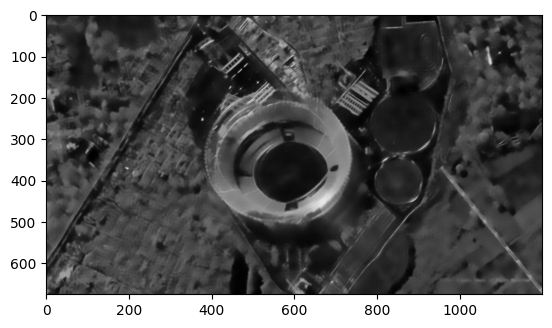

In [ ]:
plt.imshow(nlm_3, cmap="gray")

In [ ]:
def calculate_metrics(original, filtered):
    mse = np.mean(
        (original.astype(np.float64) -
         filtered.astype(np.float64)) ** 2
    )

    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 10 * np.log10((255 ** 2) / mse)

    return mse, psnr

In [ ]:
results = {
    "Без фильтрации": image_noise_gauss,
    "Медианный 3x3": median_gauss_3,
    "Медианный 5x5": median_gauss_5,
    "Медианный 7x7": median_gauss_7,
    "Гауссовский 3x3": gauss_3,
    "Гауссовский 5x5": gauss_5,
    "Гауссовский 7x7": gauss_7,
    "Билатеральный 1": bilateral_1,
    "Билатеральный 2": bilateral_2,
    "Билатеральный 3": bilateral_3,
    "NLM h=10": nlm_1,
    "NLM h=20": nlm_2,
    "NLM h=30": nlm_3
}

In [ ]:
metrics = {}

for name, filtered in results.items():
    mse, psnr = calculate_metrics(image_gray, filtered)
    metrics[name] = (mse, psnr)

for name, (mse, psnr) in sorted(
    metrics.items(),
    key=lambda item: item[1][1],
    reverse=True
):
    print(f"{name:20}  MSE = {mse:8.2f}  PSNR = {psnr:6.2f} dB")

Медианный 3x3         MSE =   214.22  PSNR =  24.82 dB
Билатеральный 1       MSE =   242.79  PSNR =  24.28 dB
Гауссовский 3x3       MSE =   250.52  PSNR =  24.14 dB
Медианный 5x5         MSE =   275.48  PSNR =  23.73 dB
Гауссовский 5x5       MSE =   276.18  PSNR =  23.72 dB
NLM h=20              MSE =   285.78  PSNR =  23.57 dB
Гауссовский 7x7       MSE =   318.70  PSNR =  23.10 dB
Билатеральный 2       MSE =   325.37  PSNR =  23.01 dB
Медианный 7x7         MSE =   330.84  PSNR =  22.93 dB
NLM h=30              MSE =   387.28  PSNR =  22.25 dB
NLM h=10              MSE =   417.10  PSNR =  21.93 dB
Билатеральный 3       MSE =   446.30  PSNR =  21.63 dB
Без фильтрации        MSE =   449.39  PSNR =  21.60 dB


In [ ]:
#лучший Медианный 3x3